In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data"
TRAIN_DIR = f"{DATA_DIR}\\Train"

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
NUM_CLASSES = 43
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True
)

Found 39209 files belonging to 43 classes.
Using 31368 files for training.


### Validating data

In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=False
)

Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


In [5]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print("Class names:", class_names)

Number of classes: 43
Class names: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


### Visualizing the processed images

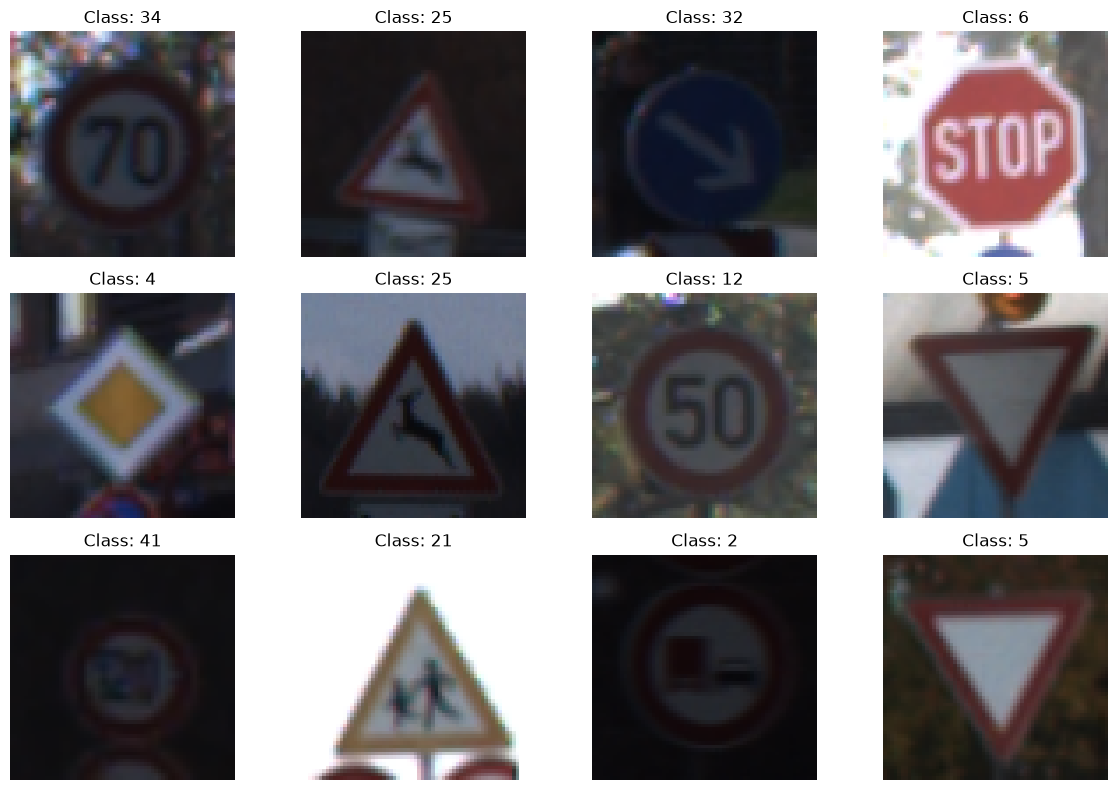

In [8]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Class: {labels[i].numpy()}")
        plt.axis("off")
plt.tight_layout()
plt.show()

### Data augmentation

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.10, 0.10),
    tf.keras.layers.RandomContrast(0.10)
])

### Normalize images

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE)

### Performance optimization

In [11]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)